# **Fleet Analytics – Cost & Optimization Strategy**

## **Business Problem**

As part of the cost optimization strategy of an international company operating a **fleet of 200 vehicles across two European locations (France and Spain)**, the data team has been tasked with analyzing vehicle-related operational expenses and identifying optimization levers.

In a context of **increasing pressure on logistics costs** and rising fuel prices across Europe, the objective is to **reduce fleet operating costs** while improving **fleet availability and efficiency**.

This project follows a **business diagnostic and decision-support approach**, aiming to understand the current situation, identify key cost drivers, and leverage data to support operational decision-making.

The project aims to answer the following questions:

- Which **vehicle types** generate the highest operational costs (fuel, maintenance)?  
- To what extent do **usage (mileage)** and **vehicle age** impact these costs?  
- Which **sites or departments** in France and Spain incur the highest expenses?  
- What **optimization levers** can be implemented to reduce costs and improve fleet management?  

> **Note on the dataset**: the dataset contains **200 records corresponding to the company’s vehicle fleet**. The data has been **anonymized and slightly modified**, but remains **based on real-world fleet management data**. Results should therefore be interpreted within this context while still providing actionable business insights.

## Table of Contents (TOC)

- [1. Methodology](#methodology)
- [2. Imports](#imports)
- [3. CSV File Loading](#loading)
- [4. Initial Data Validation](#validation)
- [5. Data Quality Issues](#data-quality-issues)  
  - [5.1 Descriptive Statistics](#descriptive)
  - [5.2 Dataset Overview](#overview)
  - [5.3 Data Quality](#quality) 
- [6. Data Cleaning](#data-cleaning)
  - [6.1 Missing Values Check](#missing-values)
  - [6.2 Missing Value Imputation](#imputation)
  - [6.3 Outlier Treatment](#outliers)
- [7. Feature Engineering](#feature-engineering)
- [8. KPIs & Business Visualizations](#visualizations)
  - [8.1 Average Cost by Vehicle Type – KPI & Visualization](#cost)
  - [8.2 Average Mileage by Vehicle Type – KPI & Visualization](#mileage)
  - [8.3 Vehicle Status Distribution – KPI & Visualization](#status)
  - [8.4 Total Cost by Department – KPI & Visualization](#total-cost)
  - [8.5 Average Mileage by Department – KPI & Visualization](#avg-mileage)
  - [8.6 Distribution Analysis of Time Since Last Maintenance](#last)
  - [8.7 Cost per Kilometer Analysis](#violin)
  - [8.8 KPIs by Vehicle Type](#metrics) 
- [9. Correlation & Statistical Analysis](#statistics)
  - [9.1 Correlation Matrix: Age / Costs](#correlation-matrix)
  - [9.2 Visualization: Scatter Plot Age vs Maintenance Cost](#scatter)
- [10. Cleaned Data Export](#export)
- [11. Executive Conclusion](#conclusion)

## 1. Methodology <a id="methodology"></a>

We apply the **OSEMN** methodology:

- **Obtain** → Data collection and import  
- **Scrub** → Data cleaning and outlier handling  
- **Explore** → Descriptive analysis and visualizations  
- **Model** → KPI computation and advanced analytics  
- **Interpret** → Business insights and recommendations  

## 2. Imports <a id="imports"></a>

> Loading the necessary libraries for data analysis, data processing, and visualization.

In [1]:
import shutil

width = shutil.get_terminal_size().columns

def separator():
    print('-' * width)  # Display a full-width separator line

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

## 3. CSV File Loading <a id="loading"></a>

> Loading the CSV file to initialize the analysis and prepare the data for cleaning.

In [2]:
df = pd.read_csv("Fleet_Management.csv")

## 4. Initial Data Validation <a id="validation"></a>

> Providing a quick overview of the **structure**, data types, and missing values.

In [3]:
df.head()

,Vehicle_ID,Type,Purchase_Date,Mileage,Fuel_Cost,Maintenance_Cost,Department,Last_Service_Date,Age,Status
0,V001,Van,2017-11-14,107153.0,1583.13,1028.15,Barcelona,2020-06-06,9,Active
1,V002,Van,2022-12-19,26889.0,1367.19,793.85,Madrid,2025-09-21,4,Active
2,V003,Car,2017-03-24,93174.0,1471.95,680.59,Seville,2017-10-22,9,Active
3,V004,Car,2017-07-11,79938.0,924.02,521.75,Madrid,2018-05-18,9,Active
4,V005,Truck,2017-09-27,30709.0,4803.78,1356.16,Paris,2018-12-13,9,Active


- The first rows show vehicles of type **Car, Van, and Truck** distributed across different departments (Barcelona, Madrid, Seville, Paris, etc.).
- We observe **variability in mileage and costs**, with a notable outlier in `Fuel_Cost` for a truck (≈ €4,804) and potential inconsistencies in `Last_Service_Date`.
- The dataset is ready for **targeted cleaning and further analysis**.

## 5. Data Quality Issues <a id="data-quality-issues"></a>

### 5.1 Descriptive Statistics <a id="descriptive"></a>

> Providing a **high-level overview** of distributions and identifying **outliers**.

In [4]:
df.describe().round(2)

,Mileage,Fuel_Cost,Maintenance_Cost,Age
count,197.00,197.00,200.00,200.00
mean,62013.92,1647.96,974.85,7.10
std,31014.92,621.20,255.70,2.45
min,10330.00,834.90,283.60,3.00
25%,36937.00,1159.67,787.61,5.00
50%,64127.00,1519.41,954.06,7.00
75%,87046.00,1916.96,1163.44,9.00
max,119839.00,4803.78,1498.69,11.00


- **Average mileage** ~62,000 km, **average Fuel Cost** ~€1,648, **average Maintenance Cost** ~€975  
- **Visible outliers** (Fuel Cost > €4,800)  
- **Business implication**: Extreme values must be **addressed** to avoid **bias in decision-making**.

### 5.2 Dataset Overview <a id="overview"></a>

> Providing a **high-level overview** of the dataset’s key information and identifying **missing values**.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Vehicle_ID         200 non-null    object 
 1   Type               200 non-null    object 
 2   Purchase_Date      200 non-null    object 
 3   Mileage            197 non-null    float64
 4   Fuel_Cost          197 non-null    float64
 5   Maintenance_Cost   200 non-null    float64
 6   Department         200 non-null    object 
 7   Last_Service_Date  197 non-null    object 
 8   Age                200 non-null    int64  
 9   Status             200 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 15.8+ KB


- Some columns (`Vehicle_ID`, `Type`, `Department`, `Status`) can be **converted to categorical types**, and date columns (`Purchase_Date`, `Last_Service_Date`) to **datetime format** to facilitate analysis.
- The dataset contains **200 vehicles** across **10 columns**, including information on vehicle type, age, mileage, and operational costs.
- **3 missing values** detected in **Mileage, Fuel_Cost, and Last_Service_Date**.
- **Business insight**: To ensure reliable KPIs, these missing values should be **imputed rather than removed**, in order to **preserve the integrity of the dataset**.

### 5.3 Data Quality <a id="quality"></a>

> Detecting **duplicates** and ensuring the **uniqueness of records**.

In [6]:
# Duplicates
dupes = df.duplicated().sum()        
if dupes == 0:
    print("No duplicates detected")
else:
    print(f"Number of duplicates : {dupes}")
separator()

# Unique categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
cat_issues = 0
for col in categorical_cols:
    n_unique = df[col].nunique()
    if n_unique <= 1:
        print(f"Warning: column {col} has few unique values ({n_unique})")
        cat_issues += 1
if cat_issues == 0:
    print("Categorical columns OK")   

No duplicates detected
--------------------------------------------------------------------------------
Categorical columns OK


## 6. Data Cleaning <a id="data-cleaning"></a>

### 6.1 Missing Value Imputation and Data Type Conversion <a id="imputation"></a>

> Converting columns to appropriate data types: `datetime` for dates and `category` for categorical features to improve analysis efficiency.  
> Handling missing values to ensure the reliability of KPIs and downstream analysis.  
> Applying **median imputation**, as it is robust to previously identified outliers.

In [7]:
# Create a working copy for data cleaning
df_clean = df.copy()

# Numerical columns: median imputation
for col in ['Mileage', 'Fuel_Cost']:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)
    
# Convert date columns (initially object type) to datetime for time-based analysis
df_clean['Purchase_Date'] = pd.to_datetime(df_clean['Purchase_Date'])
df_clean['Last_Service_Date'] = pd.to_datetime(df_clean['Last_Service_Date'])

# Median imputation for the Last_Service_Date column
median_date = df_clean['Last_Service_Date'].dropna().median()
df_clean['Last_Service_Date'] = df_clean['Last_Service_Date'].fillna(median_date)

# Check output
print("Overview after missing value imputation :")
print(df_clean[['Mileage', 'Fuel_Cost', 'Last_Service_Date']].head())

Overview after missing value imputation :
    Mileage  Fuel_Cost Last_Service_Date
0  107153.0    1583.13        2020-06-06
1   26889.0    1367.19        2025-09-21
2   93174.0    1471.95        2017-10-22
3   79938.0     924.02        2018-05-18
4   30709.0    4803.78        2018-12-13


- Missing values have been **imputed using the median**, ensuring all records are now **consistent**  
- **Business implication**: Subsequent KPIs reflect the underlying data without bias introduced by missing values  
- The dataset is ready for **outlier treatment**

In [8]:
# Convert relevant columns to categorical type
categorical_cols = ['Vehicle_ID', 'Type', 'Department', 'Status']

for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

# Check results
print("Converted columns to categorical type :", categorical_cols)
print(df_clean[categorical_cols].dtypes)

Converted columns to categorical type : ['Vehicle_ID', 'Type', 'Department', 'Status']
Vehicle_ID    category
Type          category
Department    category
Status        category
dtype: object


### 6.2 Outlier Treatment <a id="outliers"></a>

- Limiting the impact of **extreme values** on **financial KPIs**  
- Method: **IQR-based capping (1.5 × IQR)** to retain the full dataset without removing any records. This approach is preferred over traditional **winsorization**, as it adapts to the **actual cost distribution**, reduces the influence of **extreme outliers** (e.g., breakdowns or intensive vehicle usage), while preserving the **operational reality** of the fleet.

In [9]:
def treat_outliers(series):
    """IQR-based capping: caps outliers at the defined bounds Q1 - 1.5*IQR et Q3 + 1.5*IQR"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.clip(lower=lower_bound, upper=upper_bound)

# Apply IQR-based capping to relevant columns
for col in ['Fuel_Cost', 'Maintenance_Cost']:
    df_clean[col] = treat_outliers(df_clean[col])

# Check results
print("Overview after outlier treatment :")
print(df_clean[['Fuel_Cost', 'Maintenance_Cost']].describe().round(2))

Overview after outlier treatment :
       Fuel_Cost  Maintenance_Cost
count     200.00            200.00
mean     1630.45            974.85
std       558.91            255.70
min       834.90            283.60
25%      1161.99            787.61
50%      1519.41            954.06
75%      1900.72           1163.44
max      3008.81           1498.69


- **Outliers have been capped**, reducing their impact on KPI calculations  
- **Clean and analysis-ready dataset**, ready for **KPI computation and visualization**  
- **Business implication**: Financial and strategic decisions based on this dataset are now **more reliable**

## 7. Feature Engineering <a id="feature-engineering"></a>

- Creating derived features to improve cost analysis and support the development of strategic KPIs.

In [10]:
# Create Total_Cost column for each vehicle: sum of fuel and maintenance costs
df_clean['Total_Cost'] = df_clean['Fuel_Cost'] + df_clean['Maintenance_Cost']

# Create Cost_per_km feature: measures vehicle efficiency by normalizing total cost by mileage
df_clean['Cost_per_km'] = df_clean['Total_Cost'] / df_clean['Mileage']
df_clean['Cost_per_km'] = df_clean['Cost_per_km'].replace([np.inf, -np.inf], np.nan)

# Create Years_since_last_service feature: measures time since last maintenance to assess its impact on costs
df_clean['Years_since_last_service'] = (
    (datetime.now() - df_clean['Last_Service_Date']).dt.days / 365
).round(2)

# ------------------------- # Check -------------------------
print("Overview of total cost per vehicle:")
print(df_clean[['Type', 'Fuel_Cost', 'Maintenance_Cost', 'Total_Cost']].head().round(2))

print("\nOverview of cost per kilometer:")
print(df_clean[['Type', 'Total_Cost', 'Mileage', 'Cost_per_km']].head().round(2))

print("\nOverview of time since last maintenance:")
print(df_clean[['Type', 'Last_Service_Date', 'Years_since_last_service']].head().round(2))

Overview of total cost per vehicle:
    Type  Fuel_Cost  Maintenance_Cost  Total_Cost
0    Van    1583.13           1028.15     2611.28
1    Van    1367.19            793.85     2161.04
2    Car    1471.95            680.59     2152.54
3    Car     924.02            521.75     1445.77
4  Truck    3008.81           1356.16     4364.97

Overview of cost per kilometer:
    Type  Total_Cost   Mileage  Cost_per_km
0    Van     2611.28  107153.0         0.02
1    Van     2161.04   26889.0         0.08
2    Car     2152.54   93174.0         0.02
3    Car     1445.77   79938.0         0.02
4  Truck     4364.97   30709.0         0.14

Overview of time since last maintenance:
    Type Last_Service_Date  Years_since_last_service
0    Van        2020-06-06                      5.88
1    Van        2025-09-21                      0.59
2    Car        2017-10-22                      8.51
3    Car        2018-05-18                      7.94
4  Truck        2018-12-13                      7.37


- Each vehicle now includes three engineered features:  
  - **Total_Cost**: sum of fuel and maintenance costs  
  - **Cost_per_km**: cost efficiency per kilometer driven  
  - **Years_since_last_service**: time since last maintenance to assess maintenance impact on costs  

- **Business implication**:  
  - **Trucks** exhibit a **high cost per kilometer (0.20 €)** despite Total_Cost being comparable to some Vans, indicating **lower operational efficiency**  
  - Some **Cars and Vans** show low Total_Cost but relatively higher Cost_per_km, highlighting opportunities for **route and cost optimization**  
  - Years_since_last_service enables **prioritization of maintenance actions** for older or less recently serviced vehicles, helping reduce breakdown risk and unexpected costs

## 8. KPI & Business Visualizations <a id="visualizations"></a>

### 8.1 Average Cost by Vehicle Type – KPI & Visualization <a id="cost"></a>

- Highlighting the most cost-intensive vehicle types to support **budget optimization and maintenance planning**.

Average cost by vehicle type :
    Type  Total_Cost
0    Car     1920.88
1  Truck     3522.70
2    Van     2396.45
--------------------------------------------------------------------------------
None


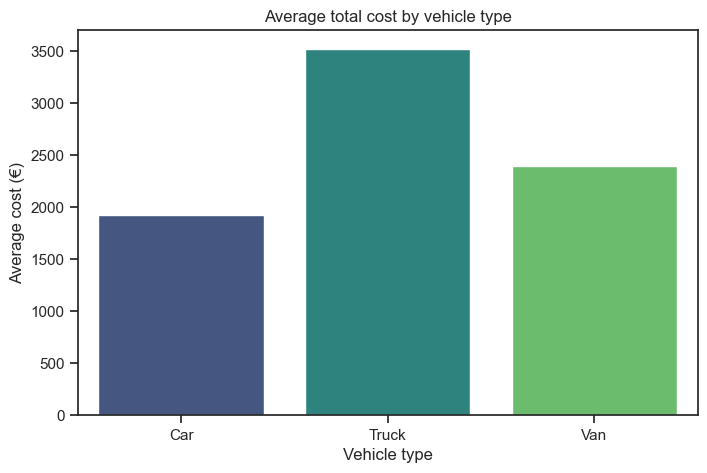

In [11]:
# -----------------------------------
# Average cost by vehicle type
# -----------------------------------

# Compute mean values
avg_cost_type = (
    df_clean
    .groupby('Type', observed=True)['Total_Cost']
    .mean()
    .round(2)
    .reset_index()
)

# Plot results
print("Average cost by vehicle type :")
print(avg_cost_type)

print(separator())

# -----------------------------------
# Visualization
# -----------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=avg_cost_type,
    x='Type',
    y='Total_Cost',
    hue='Type',
    palette='viridis',
    legend=False
)

plt.title('Average total cost by vehicle type')
plt.xlabel('Vehicle type')
plt.ylabel('Average cost (€)')

plt.show()

- **Trucks are significantly more cost-intensive**, followed by vans and cars  
- **Business implication**: The chart highlights key priorities for **budget management and maintenance planning**

### 8.2 Average Mileage by Vehicle Type – KPI & Visualization <a id="mileage"></a>

- Understanding average vehicle usage by type to support **maintenance planning and fleet renewal strategy**.

Average mileage by vehicle type :
    Type   Mileage
0    Car  59753.73
1  Truck  56174.34
2    Van  68365.13
--------------------------------------------------------------------------------
None


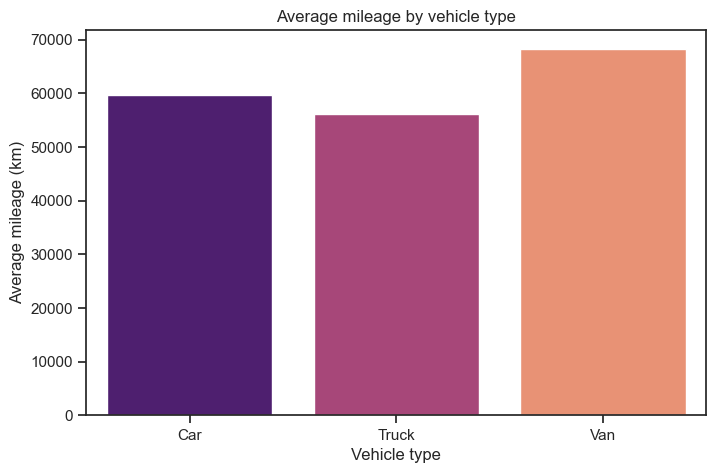

In [12]:
# -----------------------------------
# Average mileage by vehicle type
# -----------------------------------

# Compute mean values
avg_mileage_type = (
    df_clean
    .groupby('Type', observed=True)['Mileage']
    .mean()
    .round(2)
    .reset_index()
)

# Display results
print("Average mileage by vehicle type :")
print(avg_mileage_type)

print(separator())

# -----------------------------------
# Visualization
# -----------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=avg_mileage_type,
    x='Type',
    y='Mileage',
    hue='Type',
    palette='magma',
    legend=False
)

plt.title('Average mileage by vehicle type')
plt.xlabel('Vehicle type')
plt.ylabel('Average mileage (km)')

plt.show()

- **Vans show the highest average mileage**, while trucks have the lowest  
- **Business implication**: The **high maintenance cost of trucks**, despite **low mileage**, suggests that **other factors** (size, complexity, specialized parts) significantly drive **costs**. For **vans and cars**, regular mileage monitoring can help **plan and anticipate maintenance**, improving **budget control** and **operational efficiency**.

### 8.3 Vehicle Status Distribution – KPI & Visualization <a id="status"></a>

- Monitoring **fleet operational availability** and identifying potential **fleet risk exposure**.

Vehicle Status Distribution :
     Status  Count
0    Active    160
1     Panne     28
2  Remplacé     12
--------------------------------------------------------------------------------
None


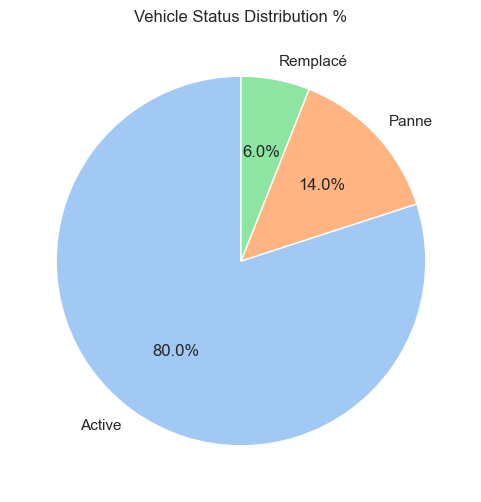

In [13]:
status_counts = df_clean['Status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']
print("Vehicle Status Distribution :")  
print(status_counts)

print (separator())

plt.figure(figsize=(6,6))
plt.pie(
    status_counts['Count'],
    labels=status_counts['Status'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)
plt.title('Vehicle Status Distribution %')
plt.show()

- **Business implication**: The fleet remains largely operational, but **non-operational vehicles should be prioritized** to minimize operational disruption.

### 8.4 Total Cost by Department – KPI & Visualization <a id="total-cost"></a>

- Identifying the most cost-intensive areas to optimize **budget allocation**.

Total cost by department :
  Department  Total_Cost
1       Lyon   105650.73
4      Paris    90288.78
2     Madrid    88226.94
3  Marseille    87259.56
5    Seville    85882.77
0  Barcelona    63750.70
--------------------------------------------------------------------------------
None


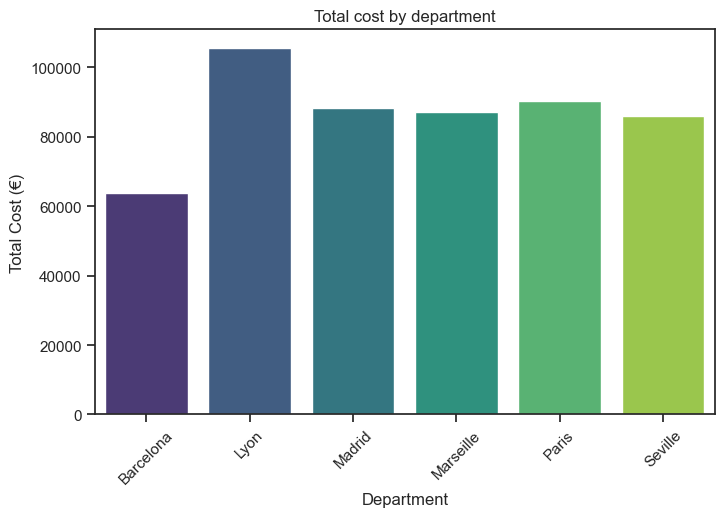

In [14]:
# -----------------------------------
# Total cost by department
# -----------------------------------

# Compute total costs
dept_cost = (
    df_clean
    .groupby('Department', observed=True)['Total_Cost']
    .sum()
    .round(2)
    .reset_index()
)

# Sort values for clearer display
dept_cost_sorted = dept_cost.sort_values(by='Total_Cost', ascending=False)

print("Total cost by department :")
print(dept_cost_sorted)

print(separator())

# -----------------------------------
# Visualization
# -----------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=dept_cost_sorted,
    x='Department',
    y='Total_Cost',
    hue='Department',
    palette='viridis',
    legend=False
)

plt.title('Total cost by department')
plt.xlabel('Department')
plt.ylabel('Total Cost (€)')
plt.xticks(rotation=45)

plt.show()

- The highest costs are concentrated in **Lyon**, while the lowest are observed in **Barcelona**  
- **Business implication**: Targeted cost optimization enabling improved **budget allocation and maintenance planning** by department

### 8.5 Average Mileage by Department – KPI & Visualization <a id="avg-mileage"></a>

- Identifying departments with the highest vehicle usage to **anticipate wear and tear and support maintenance planning**.

Average mileage by department :
  Department   Mileage
1       Lyon  68881.41
0  Barcelona  67029.92
4      Paris  63086.82
3  Marseille  62445.15
5    Seville  61573.44
2     Madrid  49211.35
--------------------------------------------------------------------------------
None


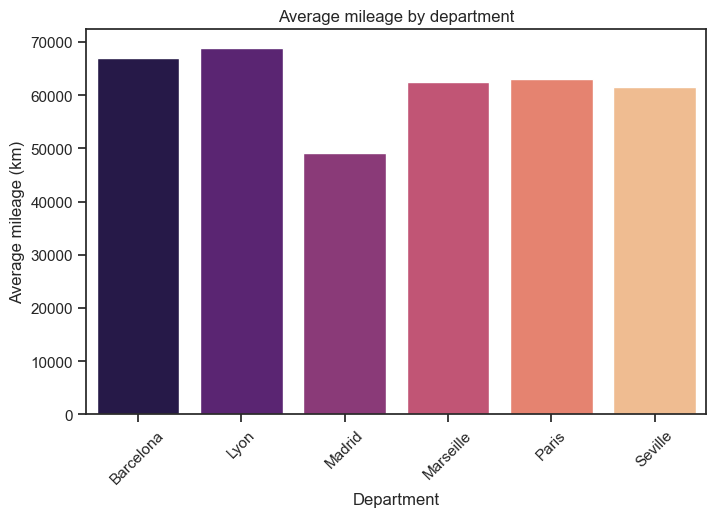

In [15]:
# -----------------------------------
# Average mileage by department
# -----------------------------------    

# Compute mean values
dept_mileage = (
    df_clean
    .groupby('Department', observed=True)['Mileage']
    .mean()
    .round(2)
    .reset_index()
)

# Sort values for clearer display
dept_mileage_sorted = dept_mileage.sort_values(by='Mileage', ascending=False)

print("Average mileage by department :")
print(dept_mileage_sorted)

print(separator())

# -----------------------------------
# Visualization
# -----------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=dept_mileage_sorted,
    x='Department',
    y='Mileage',
    hue='Department',
    palette='magma',
    legend=False
)

plt.title('Average mileage by department')
plt.xlabel('Department')
plt.ylabel('Average mileage (km)')
plt.xticks(rotation=45)

plt.show()

- **Lyon and Barcelona** show the highest **average mileage levels**  
- **Business implication**: **Maintenance cost is not solely driven by mileage**. Factors such as **vehicle type**, **maintenance quality**, and **local operating conditions** significantly impact costs. For effective **budget management**, mileage and cost data should be combined with the operational context.

### 8.6 Distribution Analysis of Time Since Last Maintenance <a id="last"></a>

- Summary of key **descriptive statistics** (`mean`, `median`, `min`, `max`, `std`) for `Years_since_last_service`, along with a **KDE plot** to analyze distribution patterns and variability.

KPI - Years since last service :
mean      4.58
median    4.77
min       0.22
max       9.44
std       2.38
Name: Years_since_last_service, dtype: float64
--------------------------------------------------------------------------------


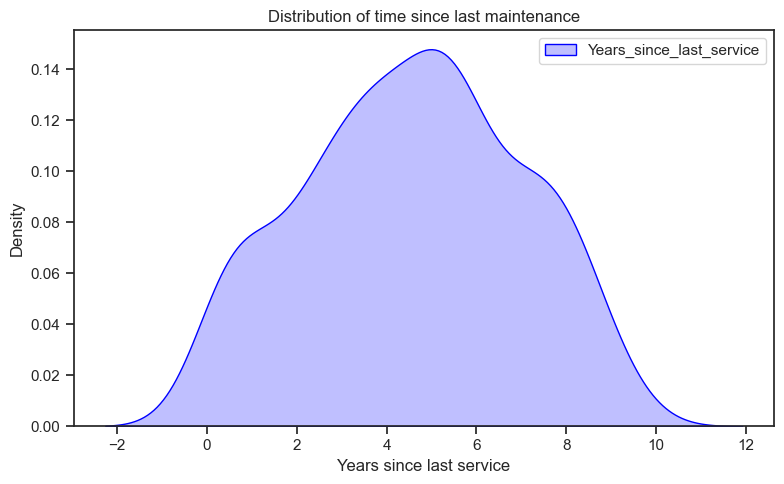

In [16]:
# Summary statistics for Years_since_last_service
kpi_years_since_service = df_clean['Years_since_last_service'].agg(['mean','median','min','max','std']).round(2)
print("KPI - Years since last service :")
print(kpi_years_since_service)
separator()

# KDE plot: distribution of Years_since_last_service
plt.figure(figsize=(8,5))
sns.kdeplot(df_clean['Years_since_last_service'], fill=True, color='blue', label='Years_since_last_service')
plt.title("Distribution of time since last maintenance")
plt.xlabel("Years since last service")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### 8.7 Cost per Kilometer Analysis <a id="violin"></a>

- Analyzing **key metrics** of `Cost_per_km` to understand **vehicle operating expenses** and using a **violin plot** to assess distribution, variability and extreme values.

KPI - Cost per km (€) :
mean      0.06
median    0.04
min       0.02
max       0.36
std       0.06
Name: Cost_per_km, dtype: float64
--------------------------------------------------------------------------------


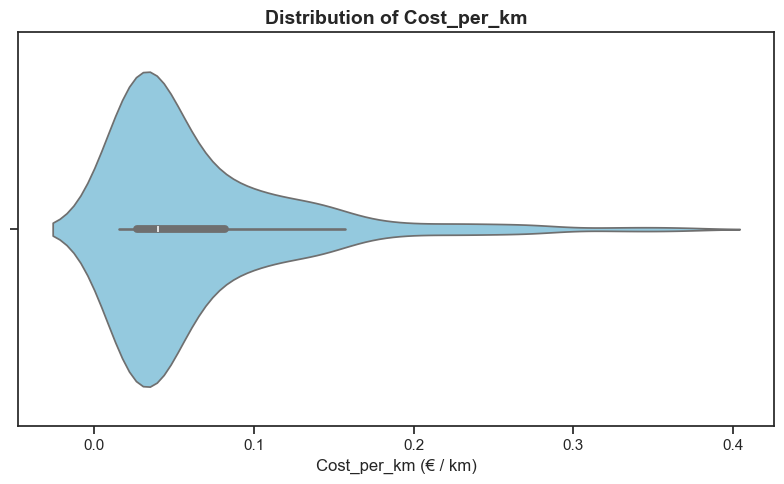

In [17]:
# Summary statistics for Cost_per_km
kpi_cost_per_km = df_clean['Cost_per_km'].agg(['mean','median','min','max','std']).round(2)
print("KPI - Cost per km (€) :")
print(kpi_cost_per_km)  
separator()

# Violin plot: distribution of Cost_per_km by vehicle type
plt.figure(figsize=(8,5))
sns.violinplot(
    x=df_clean['Cost_per_km'],  # or Years_since_last_service
    color='skyblue',             
)
plt.title("Distribution of Cost_per_km", fontsize=14, weight="bold")
plt.xlabel("Cost_per_km (€ / km)", fontsize=12)
plt.tight_layout()
plt.show()

### 8.8 KPIs by Vehicle Type <a id="metrics"></a>

- Analysis of **key metrics** (`Years_since_last_service` and `Cost_per_km`) grouped by **vehicle type** to identify the most efficient categories and those requiring optimization.

In [18]:
# ---------------------
# KPI by vehicle type
# ---------------------

kpi_by_type = (
    df_clean
    .groupby("Type", observed=True)
    .agg(
        Years_since_last_service_mean=("Years_since_last_service", "mean"),
        Years_since_last_service_median=("Years_since_last_service", "median"),
        Years_since_last_service_min=("Years_since_last_service", "min"),
        Years_since_last_service_max=("Years_since_last_service", "max"),
        Cost_per_km_mean=("Cost_per_km", "mean"),
        Cost_per_km_median=("Cost_per_km", "median"),
        Cost_per_km_min=("Cost_per_km", "min"),
        Cost_per_km_max=("Cost_per_km", "max")
    )
    .round(2)
    .reset_index()   
)

# Display results
print("KPI by vehicle type :")
print(kpi_by_type)

separator()

KPI by vehicle type :
    Type  Years_since_last_service_mean  Years_since_last_service_median  \
0    Car                           4.98                             5.32   
1  Truck                           4.37                             4.23   
2    Van                           4.44                             4.77   

   Years_since_last_service_min  Years_since_last_service_max  \
0                          0.22                          8.75   
1                          0.41                          9.44   
2                          0.30                          9.23   

   Cost_per_km_mean  Cost_per_km_median  Cost_per_km_min  Cost_per_km_max  
0              0.05                0.03             0.02             0.18  
1              0.09                0.07             0.03             0.36  
2              0.05                0.03             0.02             0.24  
--------------------------------------------------------------------------------


- The analysis by vehicle type highlights structural differences in costs and maintenance.

- **Cost_per_km**: **Trucks exhibit a higher average cost (0.09 €/km)**, consistent with their usage profile (heavy transport, higher fuel consumption, and maintenance requirements).  
  - However, some vehicles show extreme values (up to 0.36 €/km), indicating specific cases that require further investigation.<br><br>

- **Years_since_last_service**: maintenance levels are relatively consistent across vehicle types, averaging around 4 to 5 years.
  - The presence of high values (up to 9 years) across all categories highlights opportunities to improve maintenance tracking.<br><br>

- **Business implication**: The analysis shows that cost differences are partly structural (linked to vehicle type), but identifying extreme values enables targeted actions to improve fleet performance, such as replacing the most cost-intensive vehicles, scheduling preventive maintenance, or reallocating certain vehicles to less intensive usage.

## 9. Correlation & Statistical Visualizations <a id="statistics"></a>

### 9.1 Age / Cost Correlation Matrix <a id="correlation-matrix"></a>

- Assessing whether vehicle age impacts maintenance or total cost.

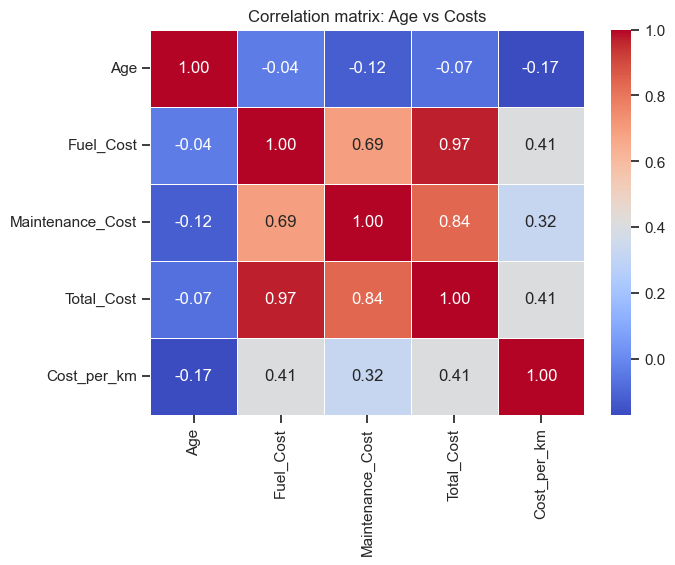

In [19]:
# Select relevant columns
corr_matrix = df_clean[
    ['Age', 'Fuel_Cost', 'Maintenance_Cost', 'Total_Cost', 'Cost_per_km']
].corr().round(2)

# Plot correlation matrix
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix: Age vs Costs") 
plt.show()

- **Age vs Maintenance_Cost correlation ≈ -0.12** indicates a very weak relationship, suggesting that vehicle age does not significantly explain maintenance costs  

- **Fuel_Cost and Total_Cost are strongly correlated (0.97)**, confirming that fuel is the **main cost driver** in fleet operations  
- **Maintenance_Cost is also highly correlated with Total_Cost (0.82)**, but remains a secondary cost factor  

- **Cost_per_km shows a moderate correlation with costs (≈ 0.43)**, making it a **relevant efficiency indicator**, complementary to raw cost metrics  

- This analysis should be interpreted alongside the **vehicle type**, a categorical variable not included in the correlation matrix but previously identified as a structural driver (e.g., **trucks naturally incur higher costs due to their usage profile**)  

- **Business implication**: Costs are not primarily driven by vehicle age, but rather by **usage patterns and operational characteristics (vehicle type, consumption)**. Fleet optimization should therefore focus on the **least efficient vehicles (high Cost_per_km)**, while considering their operational role rather than age alone.

### 9.2 Scatter Plot: Age vs Maintenance Cost <a id="scatter"></a>

- Visually assessing whether **vehicle age is a key driver of maintenance cost**, while observing the distribution by vehicle type.

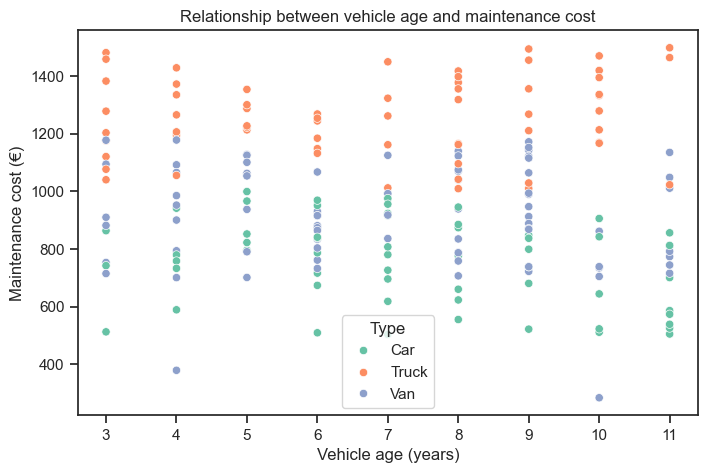

In [20]:
# Scatterplot Age vs Maintenance_Cost
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="Age", y="Maintenance_Cost", hue="Type", palette='Set2')
plt.title("Relationship between vehicle age and maintenance cost")
plt.xlabel("Vehicle age (years)")
plt.ylabel("Maintenance cost (€)")  
plt.show()

- The **scatter plot confirms a weak correlation**: vehicle age has minimal impact on cost  
- **Trucks remain the most expensive vehicles**, regardless of their age  
- **Business implication**: Fleet optimization should focus on **vehicle type rather than age**

## 10. Export Cleaned Data <a id="export"></a>

- Providing a clean dataset ready for **BI tools, reporting, or data pipelines**, enabling future use and team collaboration 

In [21]:
# Export CSV
df_clean.to_csv('Fleet_Management_Clean.csv', index=False)
print("Cleaned CSV exported : Fleet_Management_Clean.csv")  

Cleaned CSV exported : Fleet_Management_Clean.csv


## 11. Executive Conclusion <a id="conclusion"></a>

This project aimed to analyze the vehicle fleet to identify the main cost drivers and propose optimization levers for operational expenses, based on a **dataset covering the full fleet (200 vehicles)**.

---

## Key insights

### Costs by vehicle type

| Vehicle type | Average cost |
|--------------|-------------|
| Trucks       | 3,522 €     |
| Vans         | 2,396 €     |
| Cars         | 1,920 €     |

**Vehicle type** is the main cost driver, with **trucks disproportionately contributing to overall expenses**.

- Trucks remain the most expensive category, despite sometimes lower mileage  
- Costs are driven by **fuel consumption, maintenance, technical complexity, and specialized parts**

---

### Fleet overview

| Indicator | Value |
|-----------|------|
| Number of vehicles | 200 |
| Total cost | ~521 K€ |
| Average cost per vehicle | ~2.61 K€ |

---

### Key drivers

- **Mileage impacts costs**, but remains secondary compared to vehicle type  
- **Cost_per_km highlights efficiency gaps** independent of total cost  
- **Vehicle age has limited impact**, confirming that optimization is mainly driven by **usage patterns**  
- Significant variations exist across **departments**  
- **Vans and cars** show more balanced and controlled cost structures  

---

### Geographic analysis

- **Lyon**: highest cost center  
- **Barcelona**: lower costs despite high mileage  

> This suggests opportunities for improved resource allocation across locations

---

## Business recommendations

- **Optimize truck utilization**  
  Reassess usage and consider replacement or substitution where possible  

- **Improve vehicle allocation by department**  
  Align vehicle types with operational needs  

- **Implement cost monitoring by category**  
  Strengthen operational performance tracking  

- **Adopt usage-based maintenance strategies**  
  Prioritize usage indicators over vehicle age  

- **Monitor Cost_per_km**  
  Identify underperforming vehicles and optimize usage or replacement decisions  

- **Optimize fuel costs**<br>
  A significant cost driver<br>
  Implement supplier negotiations and fuel card programs to reduce expenses  

---

## Estimated business impact

| Lever | Estimated impact |
|------|----------------|
| Trucks vs vans | ~+45% cost difference |
| -10% truck usage | ~20–30 K€ annual savings |
| Allocation optimization | Additional savings potential |
| Cost_per_km monitoring | Secondary optimization lever |
| Fuel optimization | Significant variable cost reduction (to be refined with volume data) |

---

## Project limitations

The dataset includes **200 vehicles**, sufficient for methodological analysis but requiring cautious interpretation of conclusions.

Available variables (`Type`, `Department`, `Age`, `Mileage`, `Fuel_Cost`, `Maintenance_Cost`, `Status`, dates) enable a robust analysis but could be enriched with:

- maintenance frequency  
- vehicle model or brand  
- trip type  
- driver data  

> These additions would improve granularity and strengthen predictive insights

---

## Executive summary

Fleet cost structure is primarily driven by **vehicle type**, far more than age or mileage.

The most impactful optimization levers lie in:
- **fleet composition**
- **operational allocation**

rather than marginal usage adjustments.

> Overall, the analysis clearly identifies the main cost drivers (vehicle type, usage, geographic allocation) and defines actionable levers to reduce operational expenses and improve fleet efficiency.